In [78]:
import torch
import matplotlib.pyplot as plt
import os
import numpy as np
import sklearn

from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torchinfo import summary
from torch import nn
from torch.utils.data import DataLoader, Subset

# Exploratory Data Analysis

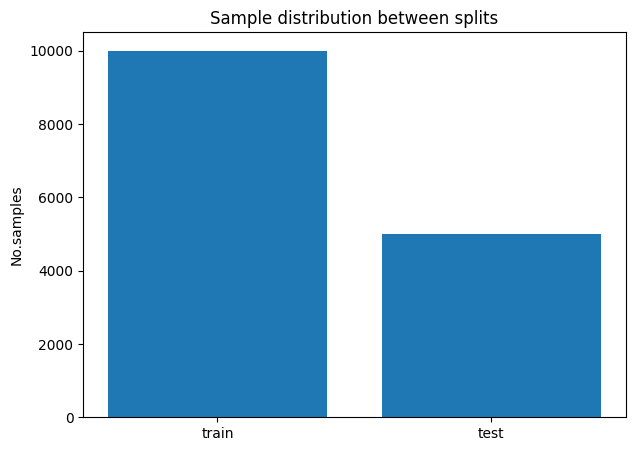

In [3]:
# Check the sample distribution between train and test set
DATA_PATH = r"C:\Users\X1 Carbon\MIAD---Electrical-Insulator\data"
sample_distribution = {}

for split in ['train', 'test']:
    total_sample = 0
    FOLDER_PATH = os.path.join(DATA_PATH, split)

    for class_name in os.listdir(FOLDER_PATH):
        CLASS_PATH = os.path.join(FOLDER_PATH, class_name)
        total_sample += len(os.listdir(CLASS_PATH))

    sample_distribution[split] = total_sample

# Plot the sample distribution
plt.figure(figsize=(7, 5))
plt.bar(sample_distribution.keys(), sample_distribution.values())
plt.title("Sample distribution between splits")
plt.ylabel("No.samples")
plt.show()
    

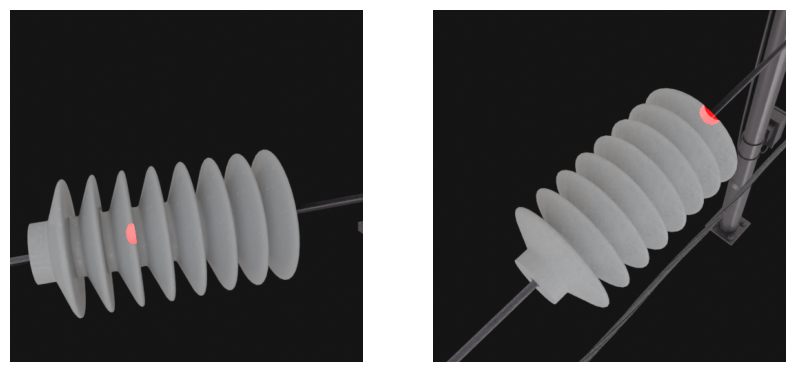

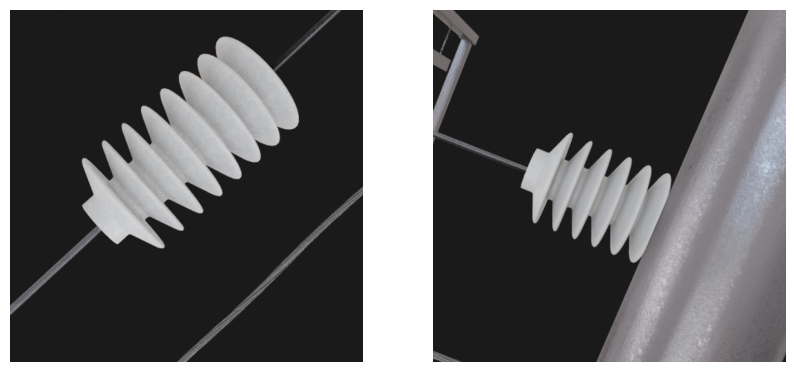

In [4]:
# Display example images
FOLDER_PATH = r"C:\Users\X1 Carbon\MIAD---Electrical-Insulator\data\test"
MASK_FOLDER = r"C:\Users\X1 Carbon\MIAD---Electrical-Insulator\data\ground_truth\broken"

for class_name in os.listdir(FOLDER_PATH):
    CLASS_PATH = os.path.join(FOLDER_PATH, class_name)
    
    # Visualize 2 images in each class
    fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))
    for i in range(2):
        IMG_NAME = os.listdir(CLASS_PATH)[i]
        IMG_PATH = os.path.join(CLASS_PATH, IMG_NAME)
        image = plt.imread(IMG_PATH)
        
        # If defective, show broken location
        if class_name == "broken":
            alpha = 0.2 # Transparency
            MASK_NAME = f"{IMG_NAME[:-4]}_mask.png" # Get corresponding mask
            MASK_PATH = os.path.join(MASK_FOLDER, MASK_NAME)

            # Overlay mask onto image
            temp = plt.imread(MASK_PATH)
            mask = np.zeros(image.shape)
            mask[:, :, 0] = temp * 255
            image = (1 - alpha) * image + alpha * mask
            image = np.clip(image, 0, 1) # Ensure pixel value is still within range 0 - 255 after overlay
            
        ax[i].imshow(image)              
        ax[i].axis("off")

plt.show()

In [6]:
# Check image dimension
image.shape

(512, 512, 3)

# Model Building

In [67]:
# Load dataset
TRAIN_FOLDER = r"C:\Users\X1 Carbon\MIAD---Electrical-Insulator\data\train"
TEST_FOLDER = r"C:\Users\X1 Carbon\MIAD---Electrical-Insulator\data\test"

# Split original train dataset into train and val dataset
temp_dataset = datasets.ImageFolder(TRAIN_FOLDER, transform=transforms.ToTensor())
sample_indices = list(range(len(temp_dataset.targets)))

train_indices, val_indices = train_test_split(sample_indices, test_size=0.3)
train_dataset = Subset(temp_dataset, train_indices)
val_dataset = Subset(temp_dataset, val_indices)
test_dataset = datasets.ImageFolder(TEST_FOLDER)

# Create Dataloader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, drop_last=False)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False, drop_last=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [73]:
# Set random seed for reproducibility
RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

In [137]:
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2, stride=2),

                                     nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2, stride=2),

                                     nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2, stride=2),

                                     nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2, stride=2))

        # Decoder
        self.decoder = nn.Sequential(nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
                                     nn.ReLU(),

                                     nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
                                     nn.ReLU(),

                                     nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
                                     nn.ReLU(),

                                     nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
                                     nn.Sigmoid()) # Use Sigmoid to ensure reconstructed pixel between 0 and 1

    def forward(self, x):
        x = self.encoder(x)
        x_reconstructed = self.decoder(x)

        return x_reconstructed

In [ ]:
# Check if output shape is correct
model = ConvAutoEncoder()
summary(model, input_size=(32, 3, 512, 512))

Layer (type:depth-idx)                   Output Shape              Param #
ConvAutoEncoder                          [32, 3, 512, 512]         --
├─Sequential: 1-1                        [32, 256, 32, 32]         --
│    └─Conv2d: 2-1                       [32, 32, 512, 512]        896
│    └─ReLU: 2-2                         [32, 32, 512, 512]        --
│    └─MaxPool2d: 2-3                    [32, 32, 256, 256]        --
│    └─Conv2d: 2-4                       [32, 64, 256, 256]        18,496
│    └─ReLU: 2-5                         [32, 64, 256, 256]        --
│    └─MaxPool2d: 2-6                    [32, 64, 128, 128]        --
│    └─Conv2d: 2-7                       [32, 128, 128, 128]       73,856
│    └─ReLU: 2-8                         [32, 128, 128, 128]       --
│    └─MaxPool2d: 2-9                    [32, 128, 64, 64]         --
│    └─Conv2d: 2-10                      [32, 256, 64, 64]         295,168
│    └─ReLU: 2-11                        [32, 256, 64, 64]         --
│

In [139]:
# Set up hyperparameters
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 0.01
OPTIMIZER= torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
LOSS_FN = nn.MSELoss()
PATIENCE = 20
BEST_VAL_SCORE = float("inf")
NO_IMPROVE = 0
EPOCHS = 200
SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=OPTIMIZER, mode='min', factor=0.1, patience=PATIENCE/2)

In [ ]:
# Training loop